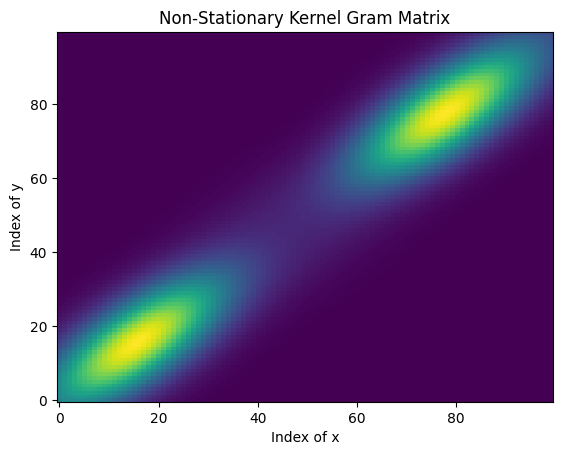

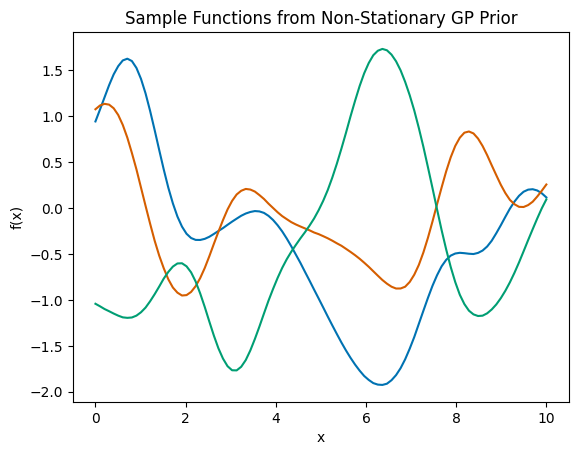

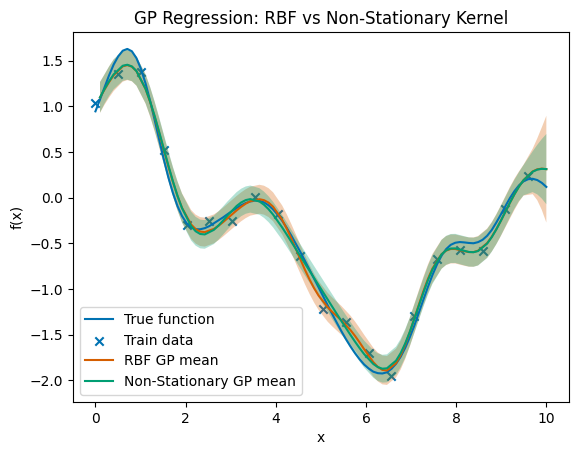

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Kernel as BaseKernel, RBF

# Use a colorblind‐friendly palette: Tableau 10
plt.rcParams['axes.prop_cycle'] = plt.cycler(
    'color',
    ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#F0E442', '#56B4E9', '#E69F00', '#000000']
)

# 1. Define the custom non-stationary kernel
class NonStationaryKernel(BaseKernel):
    def __init__(self, length_scale=1.0):
        self.length_scale = length_scale

    def __call__(self, X, Y=None, eval_gradient=False):
        if Y is None:
            Y = X
        X = np.atleast_2d(X).ravel()
        Y = np.atleast_2d(Y).ravel()
        sigma_X = 1 + 0.5 * np.sin(X)
        sigma_Y = 1 + 0.5 * np.sin(Y)
        d2 = (X[:, None] - Y[None, :]) ** 2
        K = np.outer(sigma_X, sigma_Y) * np.exp(-d2 / (2 * self.length_scale**2))
        if eval_gradient:
            # gradient w.r.t. length_scale
            grad = K * d2 / (self.length_scale**3)
            return K, grad[..., None]
        return K

    def diag(self, X):
        X = np.atleast_2d(X).ravel()
        return (1 + 0.5 * np.sin(X))**2

    def is_stationary(self):
        return False

# 2. Prepare data
x = np.linspace(0, 10, 100)
x = x.reshape(-1, 1)

# 3. Plot Gram matrix
kernel_ns = NonStationaryKernel(length_scale=1.0)
K = kernel_ns(x)
plt.figure()
plt.imshow(K, origin='lower', aspect='auto')
plt.title("Non-Stationary Kernel Gram Matrix")
plt.xlabel("Index of x")
plt.ylabel("Index of y")
plt.show()

# 4. Sample functions from the GP prior
L = np.linalg.cholesky(K + 1e-6 * np.eye(len(K)))
samples = L @ np.random.randn(len(K), 3)
plt.figure()
for i in range(3):
    plt.plot(x.ravel(), samples[:, i])
plt.title("Sample Functions from Non-Stationary GP Prior")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

# 5. Regression experiment
# True function: a sample from the same GP plus noise
f_true = samples[:, 0]
y = f_true + 0.1 * np.random.randn(len(f_true))

# Split train/test
idx = np.arange(len(x))
train_idx = idx[::5]
test_idx = np.setdiff1d(idx, train_idx)
X_train, y_train = x[train_idx], y[train_idx]
X_test, y_test = x[test_idx], f_true[test_idx]

# Fit RBF kernel GP
gp_rbf = GaussianProcessRegressor(kernel=RBF(length_scale=1.0), alpha=0.01)
gp_rbf.fit(X_train, y_train)
y_pred_rbf, std_rbf = gp_rbf.predict(X_test, return_std=True)

# Fit Non-Stationary kernel GP
gp_ns = GaussianProcessRegressor(kernel=kernel_ns, alpha=0.01)
gp_ns.fit(X_train, y_train)
y_pred_ns, std_ns = gp_ns.predict(X_test, return_std=True)

# 6. Plot predictions
plt.figure()
plt.plot(x, f_true, label="True function")
plt.scatter(X_train, y_train, label="Train data", marker='x')
plt.plot(X_test, y_pred_rbf, label="RBF GP mean")
plt.fill_between(X_test.ravel(), y_pred_rbf - 2*std_rbf, y_pred_rbf + 2*std_rbf, alpha=0.3)
plt.plot(X_test, y_pred_ns, label="Non-Stationary GP mean")
plt.fill_between(X_test.ravel(), y_pred_ns - 2*std_ns, y_pred_ns + 2*std_ns, alpha=0.3)
plt.legend()
plt.title("GP Regression: RBF vs Non-Stationary Kernel")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()


## Numpyro Implementation

sample: 100%|██████████| 1500/1500 [04:16<00:00,  5.84it/s, 1023 steps of size 1.87e-03. acc. prob=0.92]


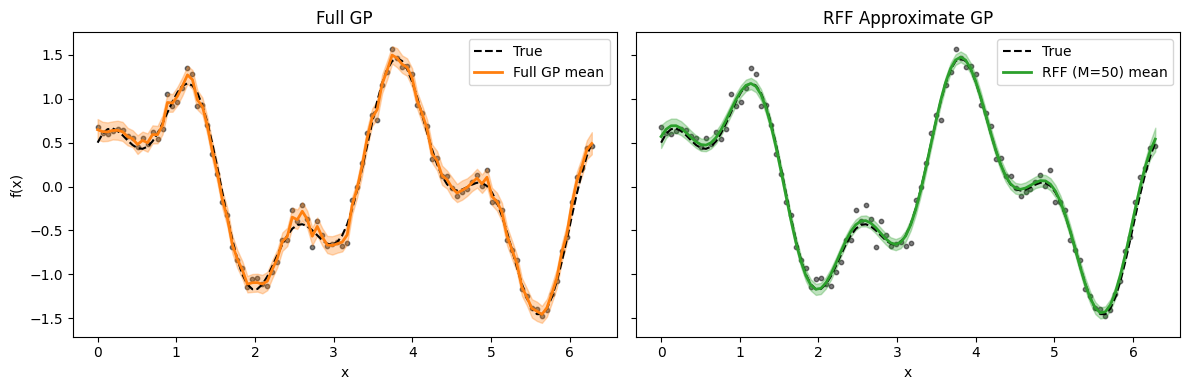

In [7]:
import numpy as np
import jax.numpy as jnp
from jax import random
import matplotlib.pyplot as plt

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive

# 1. Synthetic data
N = 100
x = np.linspace(0, 2 * np.pi, N)
f_true = np.sin(2.0 * x) + 0.5 * np.cos(5.0 * x)
noise_std = 0.1
y = f_true + noise_std * np.random.randn(N)

# 2a. Full GP model
def full_gp_model(x, y=None):
    ℓ   = numpyro.sample('ℓ',   dist.LogNormal(0.0, 0.5))
    amp = numpyro.sample('amp', dist.LogNormal(0.0, 0.5))
    σ   = numpyro.sample('σ',   dist.LogNormal(jnp.log(0.1), 0.2))

    dist_sq = (x[:, None] - x[None, :])**2
    K = amp**2 * jnp.exp(-0.5 * dist_sq / (ℓ**2))
    K += (σ**2 + 1e-6) * jnp.eye(N)

    f = numpyro.sample('f', dist.MultivariateNormal(jnp.zeros(N),
                                                   covariance_matrix=K))
    numpyro.sample('y', dist.Normal(f, σ), obs=y)

# 2b. RFF GP model
def rff_gp_model(x, y=None, M=50):
    ℓ   = numpyro.sample('ℓ',   dist.LogNormal(0.0, 0.5))
    amp = numpyro.sample('amp', dist.LogNormal(0.0, 0.5))
    σ   = numpyro.sample('σ',   dist.LogNormal(jnp.log(0.1), 0.2))

    W = numpyro.sample('W', dist.Normal(0.0, 1.0/ℓ).expand([M]))
    b = numpyro.sample('b', dist.Uniform(0.0, 2*np.pi).expand([M]))

    ϕ = amp * jnp.sqrt(2.0/M) * jnp.cos(jnp.outer(x, W) + b)
    a = numpyro.sample('a', dist.Normal(jnp.zeros(M), jnp.ones(M)))
    f = jnp.dot(ϕ, a)

    numpyro.deterministic('f', f)
    numpyro.sample('y', dist.Normal(f, σ), obs=y)

# 3. Inference
rng_key = random.PRNGKey(0)
# Full GP
mcmc_full = MCMC(NUTS(full_gp_model), num_warmup=500, num_samples=1000)
mcmc_full.run(rng_key, x=jnp.array(x), y=jnp.array(y))
samples_full = mcmc_full.get_samples()

# RFF GP (with fewer features to speed up; try M=50 or lower)
rng_key_rf = random.PRNGKey(1)
M_feats = 50
mcmc_rff = MCMC(NUTS(lambda x, y=None: rff_gp_model(x, y, M_feats)),
                num_warmup=500, num_samples=1000)
mcmc_rff.run(rng_key_rf, x=jnp.array(x), y=jnp.array(y))
samples_rff = mcmc_rff.get_samples()

# 4. Posterior predict latent f
post_full = Predictive(full_gp_model,
                       posterior_samples=samples_full,
                       return_sites=['f'],
                       parallel=True)(rng_key, x=jnp.array(x), y=None)['f']
post_full = np.array(post_full)

post_rff = Predictive(lambda x, y=None: rff_gp_model(x, y, M_feats),
                      posterior_samples=samples_rff,
                      return_sites=['f'],
                      parallel=True)(rng_key_rf, x=jnp.array(x), y=None)['f']
post_rff = np.array(post_rff)

# Summaries
mean_full = post_full.mean(0)
low_full,  high_full  = np.percentile(post_full, [2.5, 97.5], axis=0)
mean_rff  = post_rff.mean(0)
low_rff,   high_rff   = np.percentile(post_rff, [2.5, 97.5], axis=0)

# 5. Side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Full GP
ax1.plot(x, f_true,    'k--', label='True')
ax1.scatter(x, y, c='k', s=10, alpha=0.5)
ax1.plot(x, mean_full, 'C1', lw=2, label='Full GP mean')
ax1.fill_between(x, low_full, high_full, color='C1', alpha=0.3)
ax1.set_title('Full GP')
ax1.set_xlabel('x'); ax1.set_ylabel('f(x)')
ax1.legend()

# RFF GP
ax2.plot(x, f_true,   'k--', label='True')
ax2.scatter(x, y, c='k', s=10, alpha=0.5)
ax2.plot(x, mean_rff, 'C2', lw=2, label=f'RFF (M={M_feats}) mean')
ax2.fill_between(x, low_rff, high_rff, color='C2', alpha=0.3)
ax2.set_title('RFF Approximate GP')
ax2.set_xlabel('x')
ax2.legend()

plt.tight_layout()
plt.show()


## Fourth block project

In [29]:
import jax
import numpyro 
import numpyro.distributions as dist 
from numpyro.infer import Predictive, NUTS, MCMC

from quantbayes import bnn 

def BNN(X, y=None):
    """ 
    Implements the baseline one layer-BNN
    """ 
    N, D = X.shape 
    X = bnn.Linear(D, D)(X)
    X = jax.nn.tanh(X)
    X = bnn.Linear(D, 1, name="out")(X) # Here we assume regression, use num_classes for multiclass
    mu = X.squeeze()
    numpyro.deterministic("mu", mu)
    sigma = numpyro.sample("sigma", dist.Exponential(1.0)) # Learned variance 
    with numpyro.plate("data", N):
        numpyro.sample("obs", dist.Normal(mu, sigma), obs=y) # Here we assume regression and use Normal 

def SpectralCirc(X, y=None):
    N, D = X.shape
    X = bnn.SpectralCirculantLayer(D)(X)
    X = jax.nn.tanh(X)
    X = bnn.Linear(D, 1)(X)
    mu = X.squeeze()
    numpyro.deterministic("mu", mu)
    sigma = numpyro.sample("sigma", dist.Exponential(1.0)) # Learned variance 
    with numpyro.plate("data", N):
        numpyro.sample("obs", dist.Normal(mu, sigma), obs=y) # Here we assume regression and use Normal 

def AdaptiveSpectralCirc(X, y=None):
    N, D = X.shape
    X = bnn.AdaptiveSpectralCirculantLayer(D)(X)
    X = jax.nn.tanh(X)
    X = bnn.Linear(D, 1)(X)
    mu = X.squeeze()
    numpyro.deterministic("mu", mu)
    sigma = numpyro.sample("sigma", dist.Exponential(1.0)) # Learned variance 
    with numpyro.plate("data", N):
        numpyro.sample("obs", dist.Normal(mu, sigma), obs=y) # Here we assume regression and use Normal 


def run_mcmc(model, seed: int, X_train, y_train) -> dict:
    """ 
    Returns samples
    """
    key = jax.random.key(seed)
    kernel = NUTS(model)
    mcmc = MCMC(kernel, num_warmup=1000, num_samples=1000, num_chains=2)
    mcmc.run(key, X_train, y_train)
    return mcmc 

def quick_preds(model, mcmc, seed, X_test):
    key = jax.random.key(seed)
    predictive = Predictive(model, mcmc.get_samples(), num_samples=100)
    preds = predictive(key, X_test) # Here we just retunr the full posterior for downstream analysis 
    return preds 



In [ ]:
import jax.numpy as jnp
import numpy as onp
from sklearn.datasets import load_iris, load_breast_cancer, fetch_openml, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import jax.numpy as jnp
import numpy as onp
from sklearn.datasets import (
    load_breast_cancer,
    load_iris,
    load_diabetes,
    fetch_openml,
    fetch_california_housing,
    load_boston,                # if your sklearn still has it
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline


def load_and_split(name, test_size=0.2, random_state=0, scale_y=None):
    """
    Load a dataset by name, split into train/test,
    scale X with StandardScaler, optionally scale y if regression,
    detect task type and print it, and convert to JAX arrays.

    Args:
      name (str): one of
        "breast_cancer", "pima_indians_diabetes", "iris",
        "diabetes", "adult", "california_housing", "boston"
      test_size (float)
      random_state (int)
      scale_y (bool|None):
        - True: always scale y
        - False: never scale y
        - None: scale y if regression, leave raw for classification

    Returns:
      X_train_jax, X_test_jax: jnp.float32 arrays
      y_train_jax, y_test_jax: jnp.float32 arrays (scaled if scale_y else raw)
      scaler_X: fitted StandardScaler
      scaler_y: fitted MinMaxScaler if used else None

    Supported datasets (and their task types):

        - **breast_cancer**: binary classification  
        - **pima_indians_diabetes**: binary classification  
        - **iris**: multiclass classification (3 classes)  
        - **diabetes**: regression  
        - **adult**: binary classification  
        - **california_housing**: regression  
        - **boston**: regression  

    """
    # 1) Load raw data
    if name == "breast_cancer":
        data = load_breast_cancer(as_frame=True)
        X_df, y = data.data, data.target.values
    elif name == "pima_indians_diabetes":
        df = fetch_openml("pima-indians-diabetes", version=1, as_frame=True)
        X_df, y = df.data, df.target.astype(int).values
    elif name == "iris":
        data = load_iris(as_frame=True)
        X_df, y = data.data, data.target.values
    elif name == "diabetes":
        data = load_diabetes(as_frame=True)
        X_df, y = data.data, data.target.values
    elif name == "adult":
        df = fetch_openml("adult", version=2, as_frame=True).frame
        # drop rows with missing
        df = df.replace("?", onp.nan).dropna()
        y = (df["class"] == ">50K").astype(int).values
        X_df = df.drop(columns=["class"])
    elif name == "california_housing":
        data = fetch_california_housing(as_frame=True)
        X_df, y = data.data, data.target.values
    elif name == "boston":
        data = load_boston()  # deprecated in newer sklearn
        X_df, y = data.data, data.target
    else:
        raise ValueError(f"Unknown dataset {name!r}")

    # 2) Preprocess X: numeric→StandardScaler, categorical→OneHotEncoder
    numeric_cols = X_df.select_dtypes(include="number").columns.tolist()
    cat_cols     = X_df.select_dtypes(include="object").columns.tolist()
    preproc = ColumnTransformer([
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(sparse=False, handle_unknown="ignore"), cat_cols),
    ])
    X = preproc.fit_transform(X_df)

    # 3) Train/test split (stratify only for classification)
    # detect classification by integer labels with few unique
    is_class = onp.issubdtype(y.dtype, onp.integer) and onp.unique(y).size <= 20
    stratify = y if is_class else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=stratify, random_state=random_state
    )

    # 4) Detect task type
    if not is_class:
        task_type = "regression"
    elif onp.unique(y_train).size == 2:
        task_type = "binary"
    else:
        task_type = "multiclass"
    print(f"{name!r} → {task_type} task (n_classes={onp.unique(y_train).size})")

    # 5) Scale y if requested (default: only for regression)
    if scale_y is None:
        do_scale_y = (task_type == "regression")
    else:
        do_scale_y = bool(scale_y)

    scaler_y = None
    if do_scale_y:
        scaler_y = MinMaxScaler().fit(y_train.reshape(-1, 1))
        y_train_s = scaler_y.transform(y_train.reshape(-1, 1)).ravel()
        y_test_s  = scaler_y.transform(y_test.reshape(-1, 1)).ravel()
    else:
        y_train_s, y_test_s = y_train, y_test

    # 6) Convert to JAX arrays
    X_train_jax = jnp.array(X_train, dtype=jnp.float32)
    X_test_jax  = jnp.array(X_test,  dtype=jnp.float32)
    y_train_jax = jnp.array(y_train_s, dtype=jnp.float32)
    y_test_jax  = jnp.array(y_test_s,  dtype=jnp.float32)

    return X_train_jax, X_test_jax, y_train_jax, y_test_jax, preproc, scaler_y



In [30]:
from sklearn.metrics import mean_squared_error
import time
import numpy as onp

# 1) Load & split with y scaling enabled
X_tr, X_te, y_tr, y_te, scaler_X, scaler_y = load_and_split(
    "diabetes",
    scale_y=True,
)  # now y_tr, y_te ∈ [0,1]

# 2) Fit your BNN
SEED = 1
tak = time.time()
mcmc = run_mcmc(AdaptiveSpectralCirc, SEED, X_tr, y_tr)
tik = time.time()

# 3) Draw posterior predictive samples for the latent mu
preds = quick_preds(AdaptiveSpectralCirc, mcmc, SEED, X_te)
#    make sure quick_preds / Predictive was called with return_sites=["mu"]
mean_preds_scaled = preds["mu"].mean(axis=0)  # shape (n_test,)

# 4) Inverse-transform both predictions and true y back to original scale
mean_preds_unscaled = scaler_y.inverse_transform(
    mean_preds_scaled.reshape(-1, 1)
).ravel()
y_te_unscaled = scaler_y.inverse_transform(y_te.reshape(-1, 1)).ravel()

# 5) Compute RMSE in original units
rmse = onp.sqrt(mean_squared_error(y_te_unscaled, mean_preds_unscaled))
print(f"Final point estimate loss (RMSE): {rmse:.3f}")
print(f"Time taken (s): {tik-tak:.3f}")


'diabetes' → regression task (n_classes=194)


/var/folders/ch/74rww8ps6cx8x_ptd9fj5d400000gn/T/ipykernel_6346/1773178991.py:51: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(kernel, num_warmup=1000, num_samples=1000, num_chains=2)
sample: 100%|██████████| 2000/2000 [00:51<00:00, 38.74it/s, 1023 steps of size 6.42e-03. acc. prob=0.94]
/var/folders/ch/74rww8ps6cx8x_ptd9fj5d400000gn/T/ipykernel_6346/1773178991.py:57: UserWarning: Sample's batch dimension size 2000 is different from the provided 100 num_samples argument. Defaulting to 2000.
  predictive = Predictive(model, mcmc.get_samples(), num_samples=100)


Final point estimate loss (RMSE): 58.826
Time taken (s): 101.197


                            NUTS

                        | Time    | RMSE
BNN                     | 17.898  | 59.591
SpectralCirc            | 123.880 | 58.110
AdaptiveSpectralCirc    | 101.197 | 58.826

                    SVI

                | Time   | RMSE
BNN             | TBD    | TBD
SpectralCirc    |

In [17]:
# load X_tr, X_te, y_tr, y_te WITHOUT scaling y
X_tr, X_te, y_tr, y_te, scaler_X, _ = load_and_split("diabetes", scale_y=False)

# run as before
mcmc  = run_mcmc(SpectralCirc, SEED, X_tr, y_tr)
preds = quick_preds(SpectralCirc, mcmc, SEED, X_te)
mean_preds = preds["obs"].mean(axis=0)

# direct RMSE in original units:
from sklearn.metrics import mean_squared_error
rmse = mean_squared_error(np.array(y_te), np.array(mean_preds), squared=False)
print("RMSE (raw y):", rmse)


TypeError: load_and_split() got an unexpected keyword argument 'scale_y'

## MLB

In [48]:
def binary_kl(q, p):
    first_term = 0.0 if q == 0 else q * np.log(q / p)
    second_term = 0.0 if q == 1 else (1 - q) * np.log((1 - q) / (1 - p))
    return first_term + second_term

k = 100
q = k/100 
p = 0.95
bound = binary_kl(q, p)
print(bound)

0.05129329438755048


## Airline question:
Sampling i.i.d from a Bernoulli $ x \sim \sum_{i=1}^{N} \operatorname{Bernoulli}(p = 0.95) $, whats the upper bound on this event happening 100 consecutive times:
With $ p = \mathbb{E}[X] = 0.95 $ and the bad event being $\hat{p} - p = 0.05 $ we now have an epsilon to apply 

In [30]:
import numpy as np

def hoeffding(n, epsilon):
    return np.exp(-2*n*epsilon**2)

def kl_div(p_hat, q):
    q = np.clip(q, 1e-12, 1-1e-12)
    if p_hat == 0:
        first_term = 0.0
    else:
        first_term = p_hat * np.log(p_hat / q)
    if p_hat == 1:
        second_term = 0.0
    else:
        second_term = (1 - p_hat) * np.log((1 - p_hat) / (1 - q))
    return first_term + second_term

kl = kl_div(1, 0.95)
kl_bound = np.exp(-100*kl)
hoeffd = hoeffding(100, 0.05)
binomial = 0.95**100
print(f"Exact Binomial Tail: {binomial}")
print(f"Hoeffding Bound: {hoeffd}")
print(f"KL Bound: {kl_bound}")

Exact Binomial Tail: 0.0059205292203339975
Hoeffding Bound: 0.6065306597126333
KL Bound: 0.005920529220334054


## KL + binomial
$$
\underset{p \in [0,1]}{sup}\exp(-10000 KL(0.95|| p)p^{100}
$$

KL supremum: 0.006077314771520671
Optimal p:    0.95049


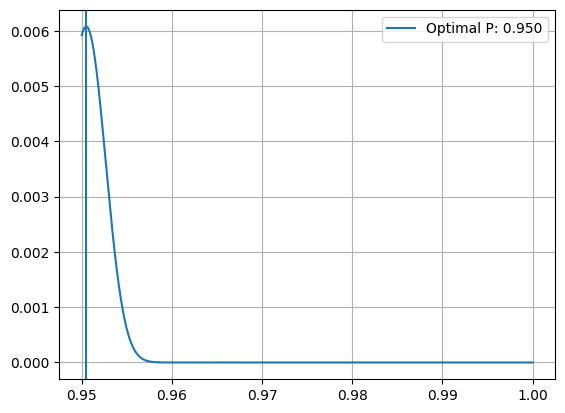

In [16]:
import numpy as np
import math

# Parameters
n1, n2 = 10_000, 100      # first‐stage and second‐stage sample sizes
q1 = 0.95                 # observed rate in stage 1

# KL‐divergence D(q||p)
def D(q, p):
    return q*math.log(q/p) + (1-q)*math.log((1-q)/(1-p))

# KL‐bound term for stage 1 and exact term for stage 2
def B_KL(p):
    return math.exp(-n1 * D(q1, p)) * (p**n2)

# Grid‐search on [q1, 1)
ps = np.linspace(q1, 1 - 1e-8, 20001)  # dense grid from 0.95 to (almost) 1
vals = np.array([B_KL(p) for p in ps])

# Find maximum
idx    = np.argmax(vals)
p_star = ps[idx]
B_star = vals[idx]

print(f"KL supremum: {B_star}")
print(f"Optimal p:    {p_star:.5f}")

plt.plot(ps, vals, label=f"")
plt.axvline(p_star, label=f"Optimal P: {p_star:.3f}")
plt.legend()
plt.grid(True)
plt.show()


## Hoeffding + binomial
$$
\underset{p \in [0,1]}{sup}\exp(-2*10000(p-0.95)^{2})p^{100}
$$

Final Bound: 0.006778


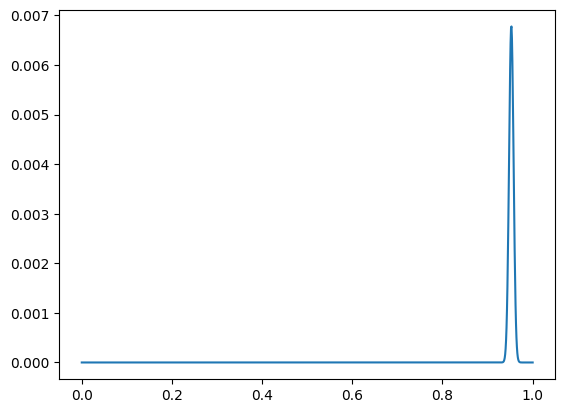

In [ ]:
# Assignment 2, a

import numpy as np
import matplotlib.pyplot as plt

def final(p):
    first = np.exp(-2*10000*(p-0.95)**2)
    second = p**100 
    return first * second 

p = np.linspace(0, 1, 1001)
bounds = final(p)
maxbound = np.max(bounds)
print(f"Final Bound: {maxbound:.4}")

plt.plot(p, bounds)
plt.show()

Exact bound: 0.000108 at p ≈ 0.9500


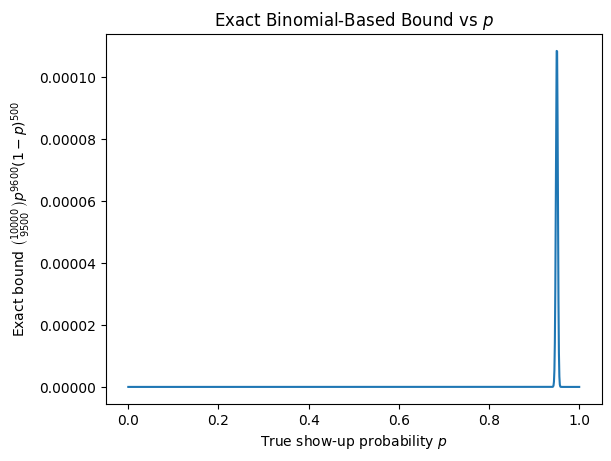

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Parameters
n = 10000          # first sample size
k1 = 9500          # successes in first sample
k2 = 100           # sample size for second stage
total_success = k1 + k2  # combined successes
fails = n - k1     # failures in first sample

# Pre-compute log of the binomial coefficient
log_binom = math.lgamma(n + 1) - math.lgamma(k1 + 1) - math.lgamma(n - k1 + 1)

def exact_bound(p):
    """Exact combined probability bound for given p."""
    return math.exp(log_binom + total_success * math.log(p) + fails * math.log(1 - p))

# Grid of p values avoiding 0 and 1
ps = np.linspace(1e-6, 1-1e-6, 1001)
bounds = np.array([exact_bound(p) for p in ps])

# Find the maximum bound
max_bound = np.max(bounds)
max_p = ps[np.argmax(bounds)]

# Display the results
print(f"Exact bound: {max_bound:.6f} at p ≈ {max_p:.4f}")

# Plotting
plt.plot(ps, bounds)
plt.xlabel("True show-up probability $p$")
plt.ylabel("Exact bound $\\binom{10000}{9500} p^{9600} (1-p)^{500}$")
plt.title("Exact Binomial-Based Bound vs $p$")
plt.show()


In [16]:
# Ghost-sample derivation for part (b)

n = 10000     # historical sample size
mh = 0.95     # observed show-up rate in historical sample
k = 100       # flight sample size
mf = 1.0      # observed show-up rate in flight sample

# Worst-case placement of p is the combined-sample proportion:
p_star = (n * mh + k * mf) / (n + k)

# Bound on P(flight all show up) under ghost-sample symmetrization:
bound_b = p_star ** k

print(f"Worst‑case p* = {p_star:.6f}")
print(f"Part (b) bound on P(event) ≈ {bound_b:.6f}")


Worst‑case p* = 0.950495
Part (b) bound on P(event) ≈ 0.006237
